Dataset Shape: (303, 15)


,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes



Missing Values:
age         0
sex         0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class Distribution:
target
1    165
0    138
Name: count, dtype: int64

Logistic Regression model trained successfully.

First 10 predicted probabilities:
[0.11689533 0.1552221  0.00776478 0.70910154 0.6677863  0.0441915
 0.79976716 0.10392639 0.97599061 0.73240905]

Threshold Comparison:


,Threshold,Accuracy,Precision,Recall,TN,FP,FN,TP
0,0.1,0.689,0.640,0.970,10,18,1,32
1,0.3,0.787,0.738,0.939,17,11,2,31
2,0.5,0.803,0.769,0.909,19,9,3,30
3,0.7,0.754,0.800,0.727,22,6,9,24
4,0.9,0.656,0.875,0.424,26,2,19,14


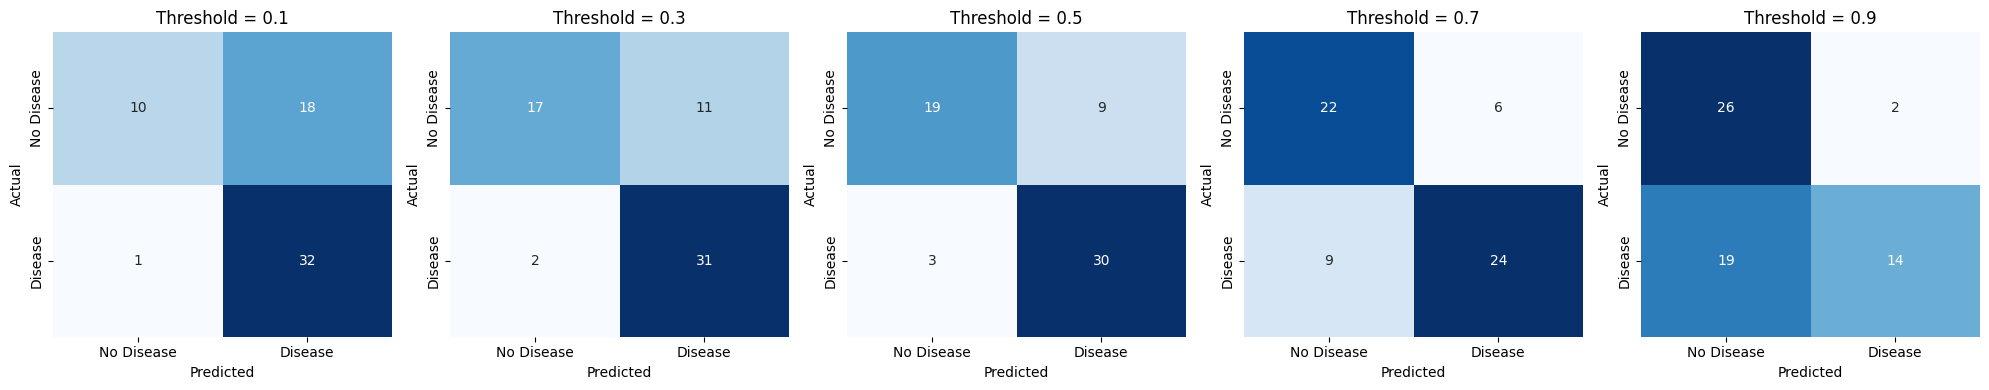

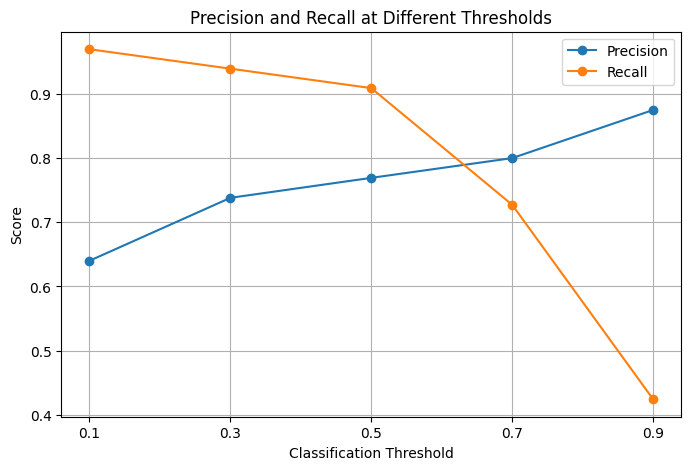

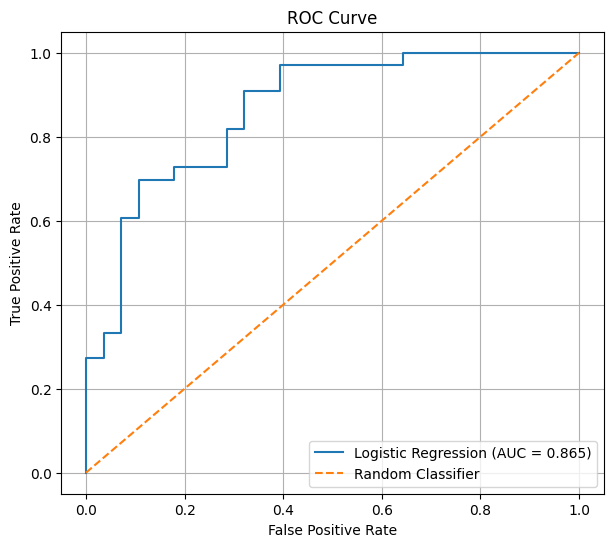

ROC-AUC Score: 0.865


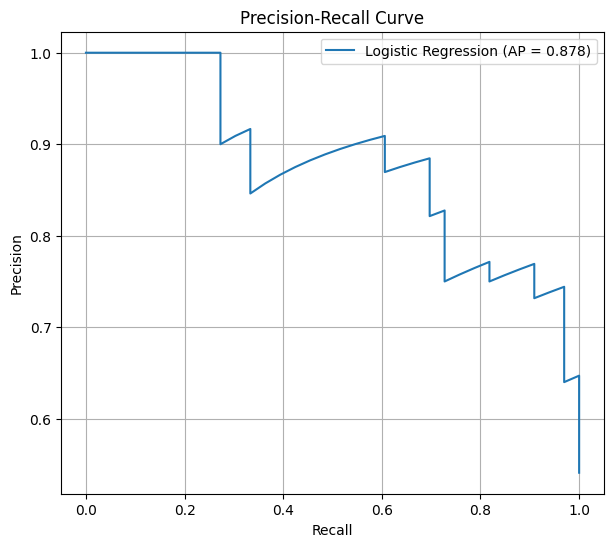

Average Precision Score: 0.878


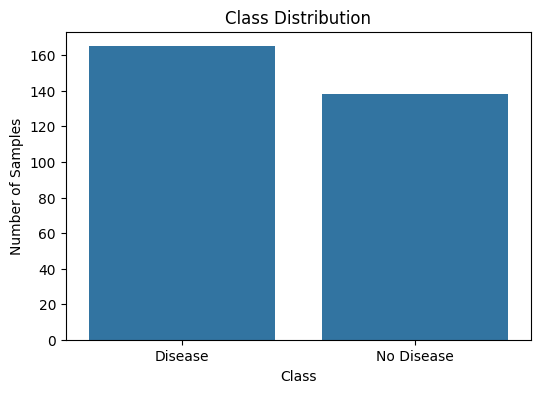


Class Distribution:
No Disease : 138
Disease    : 165

Minority class percentage: 45.54%
The dataset is reasonably balanced.

Cost-Based Threshold Analysis:


,Threshold,False Positives,False Negatives,Total Cost
0,0.1,18,1,23
1,0.3,11,2,21
2,0.5,9,3,24
3,0.7,6,9,51
4,0.9,2,19,97



Selected threshold based on FP/FN cost: 0.3

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.61      0.72        28
     Disease       0.74      0.94      0.83        33

    accuracy                           0.79        61
   macro avg       0.82      0.77      0.78        61
weighted avg       0.81      0.79      0.78        61



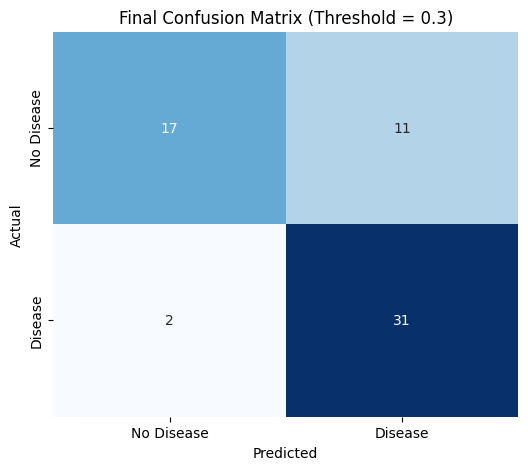

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Load dataset
df = pd.read_csv("heart disease classification dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Convert target into binary values
df["target"] = df["target"].map({"no": 0, "yes": 1})

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["target"].value_counts())

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Logistic Regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")

# Obtain predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

# Threshold analysis
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(results)

print("\nThreshold Comparison:")
display(results_df.round(3))

# Confusion matrices for each threshold
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, threshold in zip(axes, thresholds):

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    ax.set_title(f"Threshold = {threshold}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Precision and Recall vs Threshold
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall at Different Thresholds")
plt.xticks(thresholds)
plt.legend()
plt.grid()
plt.show()

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC Score:", round(roc_auc, 3))

# Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Logistic Regression (AP = {ap_score:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

print("Average Precision Score:", round(ap_score, 3))

# Class distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df["target"].map({0: "No Disease", 1: "Disease"})
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

# Class distribution percentages
class_counts = df["target"].value_counts().sort_index()

print("\nClass Distribution:")
print("No Disease :", class_counts[0])
print("Disease    :", class_counts[1])

minority_percentage = (
    class_counts.min() / class_counts.sum()
) * 100

print(f"\nMinority class percentage: {minority_percentage:.2f}%")

if minority_percentage < 40:
    print("The dataset shows some class imbalance.")
else:
    print("The dataset is reasonably balanced.")

# Cost-based threshold selection
# Missing a disease case (FN) is considered more costly than
# incorrectly predicting disease (FP).

FP_COST = 1
FN_COST = 5

cost_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    total_cost = (FP_COST * fp) + (FN_COST * fn)

    cost_results.append({
        "Threshold": threshold,
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost
    })

cost_df = pd.DataFrame(cost_results)

print("\nCost-Based Threshold Analysis:")
display(cost_df)

best_threshold = cost_df.loc[
    cost_df["Total Cost"].idxmin(),
    "Threshold"
]

print(
    f"\nSelected threshold based on FP/FN cost: {best_threshold}"
)

# Final predictions using selected threshold
final_predictions = (
    y_prob >= best_threshold
).astype(int)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["No Disease", "Disease"]
    )
)

# Final confusion matrix
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Final Confusion Matrix (Threshold = {best_threshold})")
plt.show()